In [64]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

Load the data set

In [31]:
df = pd.read_csv("../data/home_prices.csv")

In [32]:
df.columns

Index(['Square_Feet', 'Price'], dtype='str')

In [33]:
df.head()

,Square_Feet,Price
0,600,180000
1,700,210000
2,800,240000
3,900,270000
4,1000,300000


### Features and Labels

In [41]:
x = df[['Square_Feet']]
y = df[['Price']]

In [35]:
#print(x)

In [36]:
# pip install scikit-learn

In [42]:
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Train model

In [43]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[300.]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Square_Feet']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [48]:
print("Coef :" , model.coef_[0])

Coef : [300.]


In [49]:
print("Intercept:" , model.intercept_)

Intercept: [1.16415322e-10]


# Prediction

In [54]:
prediction = model.predict(x_test)

In [51]:
prediction

array([[180000.],
       [690000.],
       [630000.],
       [210000.]])

# Accuracy

In [57]:
print("MAX-Mean Absolute Error :" , mean_absolute_error(y_test,prediction))

MAX-Mean Absolute Error : 4.3655745685100555e-11


# Predict New House Price

In [60]:
sq_feat = 1750;
prediction_price = model.predict([[sq_feat]])

/media/dilan/New Volume/IJSE/4 Sem/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [61]:
print(prediction_price)

[[525000.]]


# Visualization

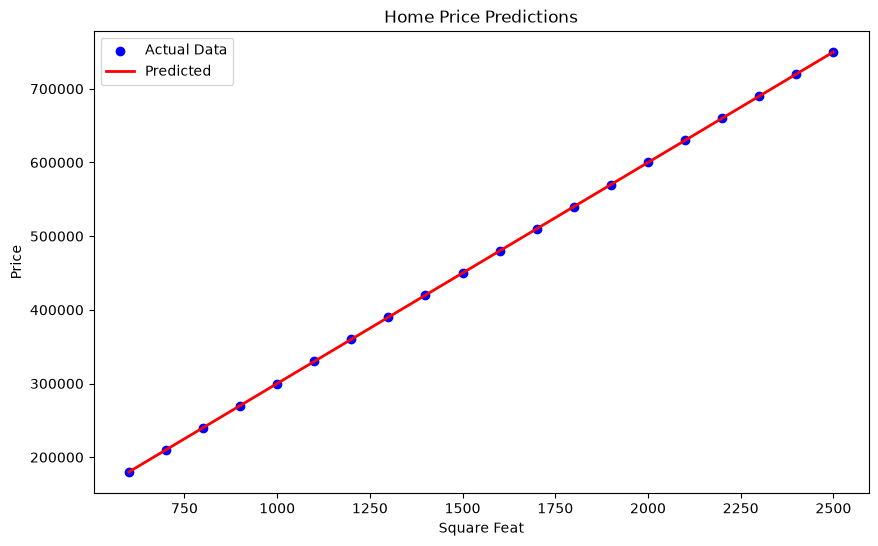

In [68]:
plt.figure(figsize=(10,6))
plt.scatter(x,y,color="blue",label="Actual Data")
plt.plot(x,model.predict(x), color="red", linewidth=2, label="Predicted")
plt.xlabel("Square Feat")
plt.ylabel("Price")
plt.title("Home Price Predictions")
plt.legend()
plt.show()